# Raw NP Waveform Traces

This notebook uses the Reach15 `.env` session-loading flow to find the selected BombCell run and save raw waveform plots under that BombCell root.

Output folders:
- `raw_mean/`
- `raw_overlay/`

## Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
# ============= Load in configuration and helper functions =============
# Add MOUSE_NAME directory to path
mouse_dir = Path().resolve().parent.parent  # notebook in analyze_bc_results/
print("Notebook:", Path().resolve())
print("Added to sys.path:", mouse_dir)
print("Exists:", mouse_dir.exists())
print("Contents:", [p.name for p in mouse_dir.iterdir()])
sys.path.append(str(Path().resolve().parent))  # adds .../mice/Reach15

print("CWD:", Path().resolve())
print("sys.path[0:5]:", sys.path[0:5])
print("Has Reach15/grant_config.py?:", (Path().resolve().parent / "grant_config.py").exists())
print("Has Reach15/helper_func/grant_config.py?:", (Path().resolve().parent / "helper_func" / "grant_config.py").exists())

Notebook: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results
Added to sys.path: C:\Users\user\Documents\github\bombcell\mice
Exists: True
Contents: ['Reach15']
CWD: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results
sys.path[0:5]: ['c:\\Users\\user\\anaconda3\\envs\\bombcell\\python311.zip', 'c:\\Users\\user\\anaconda3\\envs\\bombcell\\DLLs', 'c:\\Users\\user\\anaconda3\\envs\\bombcell\\Lib', 'c:\\Users\\user\\anaconda3\\envs\\bombcell', '']
Has Reach15/grant_config.py?: False
Has Reach15/helper_func/grant_config.py?: True


In [2]:

from helper_func.raw_waveform_batch import (
    collect_probe_contexts,
    render_raw_waveform_batch,
    render_single_raw_waveform,
    resolve_session_waveform_context,
)

print('Notebook directory:', Path().resolve())


Notebook directory: C:\Users\user\Documents\github\bombcell\mice\Reach15\analyze_bc_results


## Shared Settings

In [9]:
# Optional explicit .env path. Leave as None to use the default dotenv discovery behavior.
ENV_PATH = None

# 1, 2, or 3 corresponding to the .env session blocks.
SESSION_SELECTION = 3

# Leave as None to write raw_mean/ and raw_overlay/ directly inside the selected BombCell root.
OUTPUT_SUBDIR = None

N_CHANNELS = 384
FS = 30000
NEIGHBOR_RADIUS = 6
N_SPIKES_TO_PLOT = 40
PRE_MS = 2.0
POST_MS = 3.0
IGNORE_EDGES_S = 1.0
SEED = 0

## Resolve Session and Preview

In [10]:
session_data, cfg, bombcell_root, raw_path_by_probe = resolve_session_waveform_context(
    env_path=ENV_PATH,
    session_selection=SESSION_SELECTION,
)

session_key_map = {
    1: ('NP_FILE', 'BOMBCELL'),
    2: ('NP_FILE_01', 'BOMBCELL_01'),
    3: ('NP_FILE_02', 'BOMBCELL_02'),
}
np_key, bc_key = session_key_map[SESSION_SELECTION]

print('Recording root:', cfg['recording_root'])
print('NP file from .env:', session_data[np_key])
print('BombCell folder from .env:', session_data[bc_key])
print('BombCell root:', bombcell_root)

MOUSE loaded: Reach15
-- Behavioral Files --
BEHAVIORAL_FOLDER loaded: grant_reach15_swingDoor-christie
-- Neuropixels Sessions --
Session 1: NP_FILE=Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01 DATE=20260129 SESSION=session003 BOMBCELL=bombcell_batch_20260305_1130
Session 2: NP_FILE=Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32 DATE=20260129 SESSION=session004 BOMBCELL=NA
Session 3: NP_FILE=Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00 DATE=20260201 SESSION=session007 BOMBCELL=bombcell_batch_20260304_1536
-- Config Defaults --
RECORDINGS_ROOT loaded: H:/Grant/Neuropixels/Kilosort_Recordings
OPEN_EPHYS_CONTINUOUS_SUBPATH loaded: Record Node 103/experiment1/recording1/continuous
STRUCTURE_OEBIN_SUBPATH loaded: Record Node 103/experiment1/recording1/structure.oebin
NP20_PROBES loaded: A,C,D
Recording root: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
NP file from .e

## Batch Mode Settings

In [6]:
# Use None to batch all probes found in the selected BombCell root.
# Example: ['A', 'C', 'F']
PROBES = None

# Set to None to plot every unit on each selected probe.
MAX_UNITS_PER_PROBE = None

# Optional label filter if the BombCell quality metrics file has a label column.
# Examples: 'GOOD', 'MUA', ['GOOD', 'NON-SOMA']
LABEL_FILTER = None

# Optional explicit cluster list override.
# Example: {'A': [3, 15], 'B': [153]}
CLUSTERS_BY_PROBE = None

## Batch Mode Preview

In [ ]:
probe_contexts = collect_probe_contexts(
    bombcell_root=bombcell_root,
    raw_path_by_probe=raw_path_by_probe,
    probes=PROBES,
)

print('Probes to process:', ', '.join(probe_contexts.keys()))
for probe, context in probe_contexts.items():
    print(f"  Probe {probe}: ks_dir={context['ks_dir']}")
    print(f"            bin_path={context['bin_path']}")

## Run Batch Export

In [ ]:
batch_summary_df, output_root = render_raw_waveform_batch(
    bombcell_root=bombcell_root,
    raw_path_by_probe=raw_path_by_probe,
    probes=list(probe_contexts.keys()),
    clusters_by_probe=CLUSTERS_BY_PROBE,
    max_units_per_probe=MAX_UNITS_PER_PROBE,
    label_filter=LABEL_FILTER,
    output_subdir=OUTPUT_SUBDIR,
    n_channels=N_CHANNELS,
    fs=FS,
    neighbor_radius=NEIGHBOR_RADIUS,
    n_spikes_to_plot=N_SPIKES_TO_PLOT,
    pre_ms=PRE_MS,
    post_ms=POST_MS,
    seed=SEED,
    ignore_edges_s=IGNORE_EDGES_S,
)

print('Saved output root:', output_root)
display(batch_summary_df)

## Single Unit Settings

In [11]:
# Set these to plot one selected unit.
SELECTED_PROBE = 'A'
SELECTED_CLUSTER_ID = 32

# True shows the mean and raw overlay figures inline in the notebook while still saving them.
SHOW_SINGLE_UNIT_PLOTS = True

## Run Single Unit Export

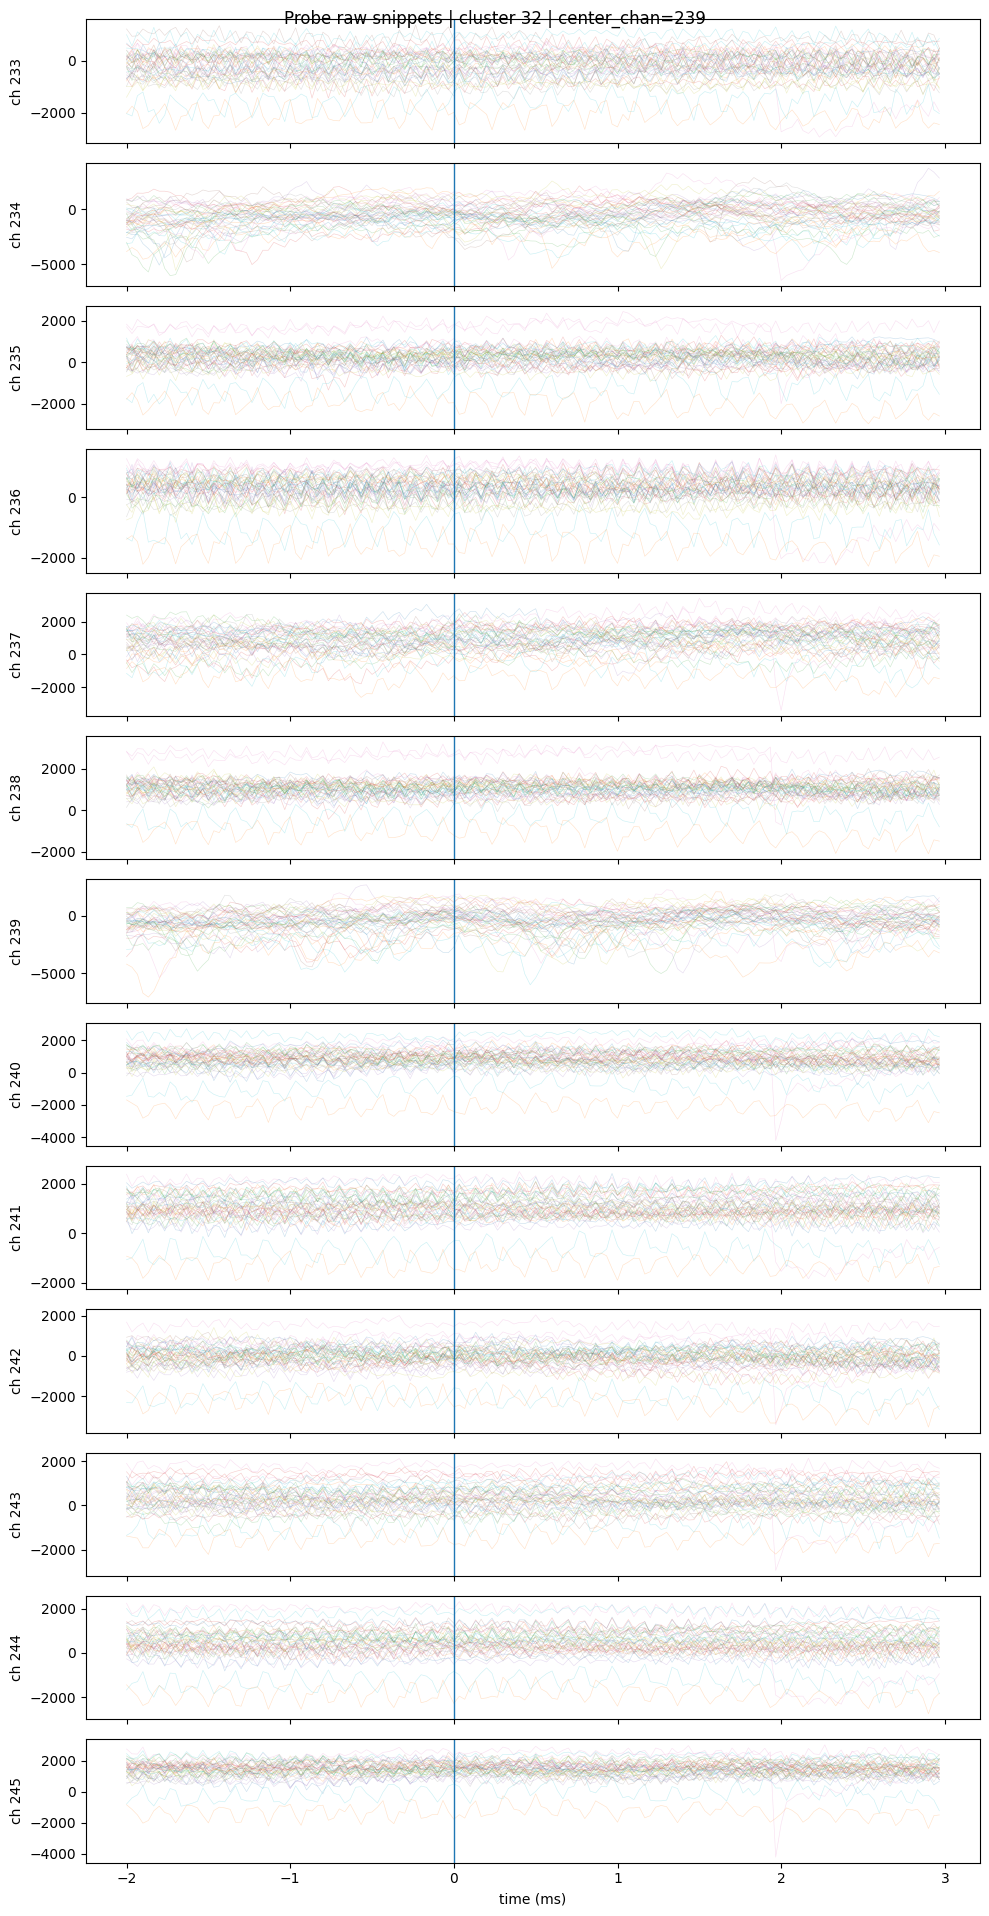

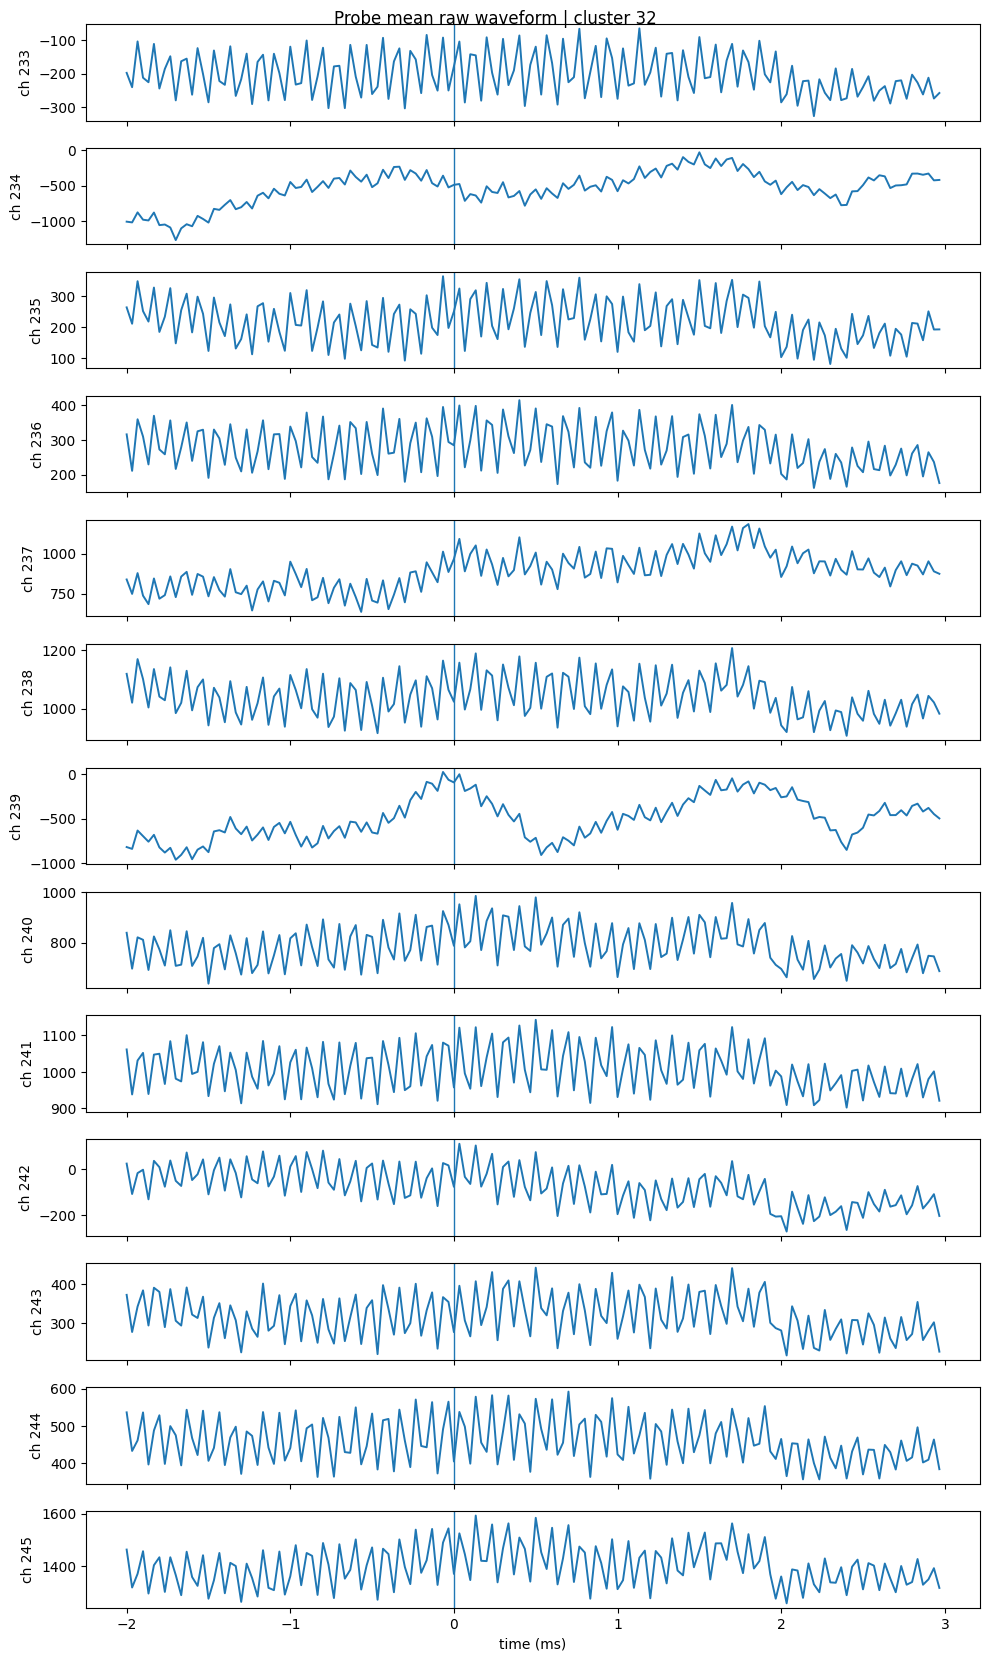

Saved output root: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260304_1536


,cluster_id,n_spikes_total,n_spikes_plotted,center_chan,neighbor_radius,channels_shown,fs,pre_ms,post_ms,probe,...,bin_path,center_channel_source,overlay_path,mean_path,status,Bombcell_unit_type,rawAmplitude,signalToNoiseRatio,nSpikes,maxChannels
0,32,8855,40,239,6,"[233, 234, 235, 236, 237, 238, 239, 240, 241, ...",30000,2.0,3.0,A,...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,quality_metrics.maxChannels,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,OK,NOISE,NaN,10.604787,8855.0,239


In [13]:
single_summary_df, single_output_root = render_single_raw_waveform(
    bombcell_root=bombcell_root,
    raw_path_by_probe=raw_path_by_probe,
    probe=SELECTED_PROBE,
    cluster_id=SELECTED_CLUSTER_ID,
    output_subdir=OUTPUT_SUBDIR,
    n_channels=N_CHANNELS,
    fs=FS,
    neighbor_radius=NEIGHBOR_RADIUS,
    n_spikes_to_plot=N_SPIKES_TO_PLOT,
    pre_ms=PRE_MS,
    post_ms=POST_MS,
    seed=SEED,
    ignore_edges_s=IGNORE_EDGES_S,
    show=SHOW_SINGLE_UNIT_PLOTS,
)

print('Saved output root:', single_output_root)
display(single_summary_df)

## Quick Summary

In [9]:
if 'batch_summary_df' in globals():
    batch_counts = batch_summary_df['status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count')
    display(batch_counts)
    batch_ok_df = batch_summary_df.loc[batch_summary_df['status'] == 'OK'].copy()
    if not batch_ok_df.empty:
        display(batch_ok_df[['probe', 'cluster_id', 'center_chan', 'center_channel_source', 'overlay_path', 'mean_path']])

if 'single_summary_df' in globals():
    display(single_summary_df[['probe', 'cluster_id', 'center_chan', 'center_channel_source', 'overlay_path', 'mean_path', 'status']])

summary_csv = Path(output_root) / 'raw_waveform_plot_summary.csv' if 'output_root' in globals() else None
print('Batch summary CSV:', summary_csv)

,probe,cluster_id,center_chan,center_channel_source,overlay_path,mean_path,status
0,A,32,143,quality_metrics.maxChannels,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,H:\Grant\Neuropixels\Kilosort_Recordings\Reach...,OK


Batch summary CSV: None
